<a href="https://colab.research.google.com/github/Megh-05/Data-Science/blob/main/Exp_No_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Dataset Shape : (60000, 28, 28, 1)
Testing Dataset Shape : (10000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,544 (1.20 MB)

 Trainable params: 314,544 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7957 - loss: 0.0454 - val_accuracy: 0.8093 - val_loss: 0.0228
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8095 - loss: 0.0216 - val_accuracy: 0.8124 - val_loss: 0.0160
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8113 - loss: 0.0177 - val_accuracy: 0.8131 - val_loss: 0.0133
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8120 - loss: 0.0158 - val_accuracy: 0.8136 - val_loss: 0.0120
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8124 - loss: 0.0147 - val_accuracy: 0.8140 - val_loss: 0.0110
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8127 - loss: 0.0139 - val_accuracy: 0.8140 - val_loss: 0.0105
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8129 - loss: 0.0133 - val_accuracy: 0.8142 - val_loss: 0.0099
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8131 - loss: 0.0128 - val_accuracy: 0.

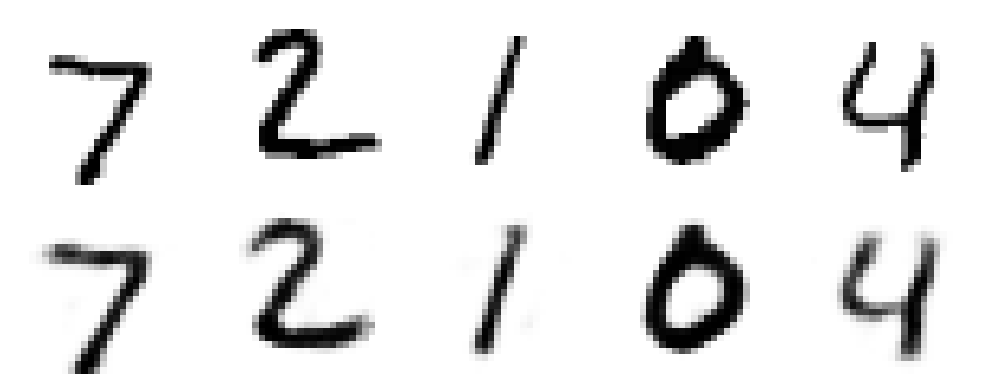

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    Reshape,
    Dropout
)

# Load Handwritten Digit Dataset

(train_images, _), (test_images, _) = mnist.load_data()

# Normalize Image Pixels

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Reshape Images

train_images = train_images.reshape(
    train_images.shape[0],
    28,
    28,
    1
)

test_images = test_images.reshape(
    test_images.shape[0],
    28,
    28,
    1
)

print("Training Dataset Shape :", train_images.shape)
print("Testing Dataset Shape :", test_images.shape)

# Encoder Network

input_layer = Input(shape=(28, 28, 1))

encoder = Flatten()(input_layer)

encoder = Dense(
    256,
    activation='relu'
)(encoder)

encoder = Dropout(0.2)(encoder)

compressed_output = Dense(
    32,
    activation='relu'
)(encoder)

# Decoder Network

decoder = Dense(
    128,
    activation='relu'
)(compressed_output)

decoder = Dense(
    784,
    activation='sigmoid'
)(decoder)

final_output = Reshape((28, 28, 1))(decoder)

# Create Autoencoder Model

digit_autoencoder = Model(
    inputs=input_layer,
    outputs=final_output
)

# Display Architecture

digit_autoencoder.summary()

# Compile Model

digit_autoencoder.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy']
)

# Train Autoencoder

training_result = digit_autoencoder.fit(
    train_images,
    train_images,
    epochs=8,
    batch_size=128,
    validation_split=0.1
)

# Evaluate Model

test_loss, test_accuracy = digit_autoencoder.evaluate(
    test_images,
    test_images
)

print("\nAutoencoder Test Loss :", test_loss)
print("Autoencoder Accuracy :", test_accuracy)

# Generate Reconstructed Digits

reconstructed_images = digit_autoencoder.predict(
    test_images[:5]
)

# Compare Original and Reconstructed Images

plt.figure(figsize=(10, 4))

for img in range(5):

    # Original Digit

    plt.subplot(2, 5, img + 1)

    plt.imshow(
        test_images[img].reshape(28, 28),
        cmap='binary'
    )

    plt.axis("off")

    # Reconstructed Digit

    plt.subplot(2, 5, img + 6)

    plt.imshow(
        reconstructed_images[img].reshape(28, 28),
        cmap='binary'
    )

    plt.axis("off")

plt.tight_layout()

plt.show()